# Experiment 1 — The Vanilla Baseline (Equal-Strength Covariates)

**Goal:** Establish the baseline failure point for the LOO benchmark under the most symmetric,
best-case setup — all observed covariates are equally informative.

**Setup**
- $D^* = X\beta_{DX} + A\beta_{DA} + \varepsilon_D$, $\quad D = \mathbf{1}[D^* > 0]$
- $Y = \tau D + X\beta_{YX} + A\beta_{YA} + \varepsilon_Y$
- $\tau_{\text{true}} = 1.0$
- $\beta_{DX} = \beta_{YX} = [0.5, 0.5, 0.5, 0.5, 0.5]$ — all covariates equal strength.
  This is the symmetric control: every $X_j$ contributes identically, so $B_{\max}$ is
  determined by any single leave-one-out covariate.
- Multiplier $m$ sweeps from $0.5$ to $2.0$ (50 steps):
  $\beta_{DA} = \beta_{YA} = 0.5m$

**Benchmark:** LOO (leave-one-out) — for each observed $X_j$, treat it as the mock omitted
confounder and compute bound $B_j$.

$B_{\max} = \max_j B_j$.

**Coverage metric:** across 250 Monte Carlo trials per multiplier,
$$\text{Coverage}(m) = \Pr\bigl(|\hat{\tau}_{\text{short}} - \tau_{\text{true}}| \le B_{\max}\bigr)$$

This is the **control experiment**. Compare its cliff location to Experiment 2 (superstar
covariate) to quantify how much a single dominant predictor extends the safe zone.

In [6]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dgp import DGPConfig, generate_data
from loo_benchmark import loo_benchmark

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [7]:
tau_true   = 1.0
n_trials   = 250

# Uniform beta — every X_j has identical strength
beta_dx    = 0.5
beta_yx    = 0.5

multipliers = np.linspace(0.5, 2.0, 50)

coverage  = []   # % trials where |tau_short - tau_true| <= B_max
mean_ovb  = []   # mean |OVB| across trials
mean_Bmax = []   # mean B_max across trials

for m_idx, multiplier in enumerate(multipliers):
    beta_da = 0.5 * multiplier
    beta_ya = 0.5 * multiplier

    covered  = 0
    ovb_vals = []
    B_vals   = []

    for trial in range(n_trials):
        seed = m_idx * n_trials + trial

        config = DGPConfig(
            num_X=5, num_A=1,
            beta_dx=beta_dx, beta_da=beta_da,
            beta_yx=beta_yx, beta_ya=beta_ya,
            seed=seed,
        )
        Y, D, X, A = generate_data(config)

        short_fit = sm.OLS(Y, sm.add_constant(np.column_stack([D, X]))).fit()
        tau_short = short_fit.params[1]

        loo_results, _ = loo_benchmark(Y, D, X)
        B_max = max(r['B'] for r in loo_results)

        ovb = abs(tau_short - tau_true)
        ovb_vals.append(ovb)
        B_vals.append(B_max)

        if ovb <= B_max:
            covered += 1

    coverage.append(100.0 * covered / n_trials)
    mean_ovb.append(np.mean(ovb_vals))
    mean_Bmax.append(np.mean(B_vals))

    print(f"m={multiplier:5.2f}  coverage={coverage[-1]:5.1f}%  "
          f"mean|OVB|={mean_ovb[-1]:.4f}  mean B_max={mean_Bmax[-1]:.4f}")

m= 0.50  coverage=100.0%  mean|OVB|=0.1012  mean B_max=0.3689
m= 0.53  coverage=100.0%  mean|OVB|=0.1089  mean B_max=0.3662
m= 0.56  coverage=100.0%  mean|OVB|=0.1327  mean B_max=0.3655
m= 0.59  coverage=100.0%  mean|OVB|=0.1393  mean B_max=0.3618
m= 0.62  coverage=100.0%  mean|OVB|=0.1558  mean B_max=0.3618
m= 0.65  coverage=100.0%  mean|OVB|=0.1684  mean B_max=0.3602
m= 0.68  coverage= 98.8%  mean|OVB|=0.1855  mean B_max=0.3571
m= 0.71  coverage= 98.8%  mean|OVB|=0.1928  mean B_max=0.3558
m= 0.74  coverage= 96.8%  mean|OVB|=0.2195  mean B_max=0.3482
m= 0.78  coverage= 98.4%  mean|OVB|=0.2364  mean B_max=0.3509
m= 0.81  coverage= 94.8%  mean|OVB|=0.2497  mean B_max=0.3479
m= 0.84  coverage= 89.2%  mean|OVB|=0.2668  mean B_max=0.3462
m= 0.87  coverage= 74.0%  mean|OVB|=0.2951  mean B_max=0.3405
m= 0.90  coverage= 70.0%  mean|OVB|=0.3054  mean B_max=0.3404
m= 0.93  coverage= 54.4%  mean|OVB|=0.3231  mean B_max=0.3345
m= 0.96  coverage= 37.6%  mean|OVB|=0.3499  mean B_max=0.3329
m= 0.99 

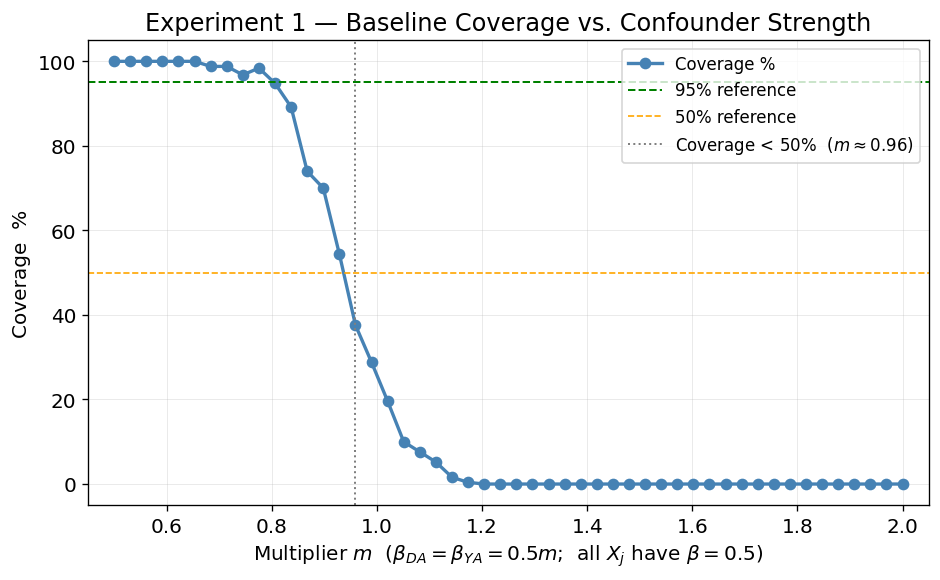

In [8]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, coverage, marker='o', linewidth=2, color='steelblue', label='Coverage %')
ax.axhline(95, linestyle='--', color='green',  linewidth=1.2, label='95% reference')
ax.axhline(50, linestyle='--', color='orange', linewidth=1.0, label='50% reference')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m$;  all $X_j$ have $\beta=0.5$)')
ax.set_ylabel('Coverage  %')
ax.set_title('Experiment 1 — Baseline Coverage vs. Confounder Strength')
ax.set_ylim(-5, 105)
ax.set_xlim(multipliers[0] - 0.05, multipliers[-1] + 0.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_01_baseline_coverage.png', bbox_inches='tight')
plt.show()

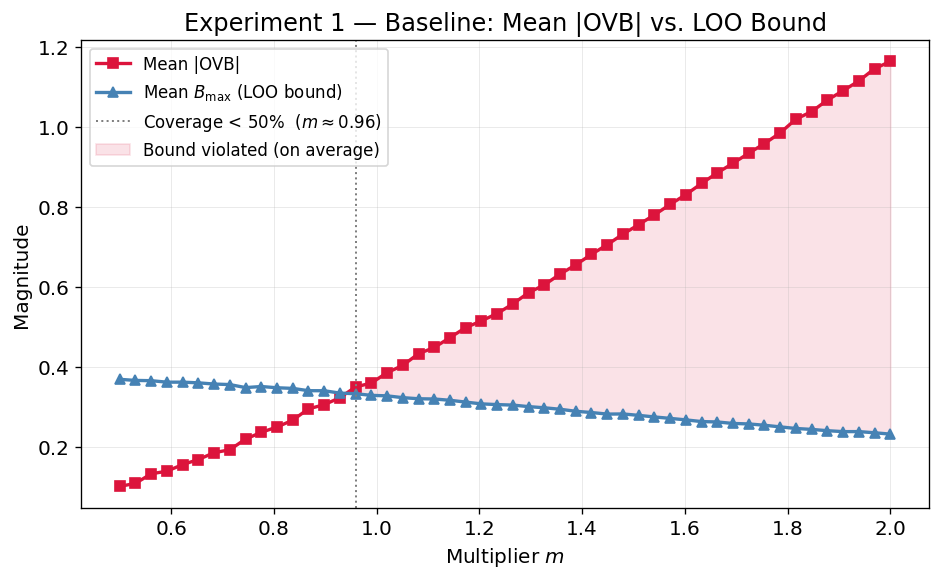

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_ovb,  marker='s', linewidth=2, color='crimson',
        label='Mean |OVB|')
ax.plot(multipliers, mean_Bmax, marker='^', linewidth=2, color='steelblue',
        label=r'Mean $B_{\max}$ (LOO bound)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ovb_arr  = np.array(mean_ovb)
bmax_arr = np.array(mean_Bmax)
ax.fill_between(multipliers, ovb_arr, bmax_arr,
                where=(ovb_arr > bmax_arr),
                color='crimson', alpha=0.12, label='Bound violated (on average)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel('Magnitude')
ax.set_title('Experiment 1 — Baseline: Mean |OVB| vs. LOO Bound')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_01_baseline_ovb_vs_bound.png', bbox_inches='tight')
plt.show()

In [10]:
import pandas as pd

df = pd.DataFrame({
    'Multiplier':   multipliers,
    'beta_DA':      0.5 * multipliers,
    'Coverage (%)': coverage,
    'Mean |OVB|':   mean_ovb,
    'Mean B_max':   mean_Bmax,
    'Bound Slack':  np.array(mean_Bmax) - np.array(mean_ovb),
})

df = df.round(4)
df.style.format(precision=4) \
        .background_gradient(subset=['Coverage (%)'], cmap='RdYlGn', vmin=0, vmax=100) \
        .background_gradient(subset=['Bound Slack'],  cmap='RdYlGn', vmin=-1, vmax=1)

,Multiplier,beta_DA,Coverage (%),Mean |OVB|,Mean B_max,Bound Slack
0,0.5000,0.2500,100.0000,0.1012,0.3689,0.2677
1,0.5306,0.2653,100.0000,0.1089,0.3662,0.2573
2,0.5612,0.2806,100.0000,0.1327,0.3655,0.2328
3,0.5918,0.2959,100.0000,0.1393,0.3618,0.2225
4,0.6224,0.3112,100.0000,0.1558,0.3618,0.2060
5,0.6531,0.3265,100.0000,0.1684,0.3602,0.1918
6,0.6837,0.3418,98.8000,0.1855,0.3571,0.1716
7,0.7143,0.3571,98.8000,0.1928,0.3558,0.1630
8,0.7449,0.3724,96.8000,0.2195,0.3482,0.1287
9,0.7755,0.3878,98.4000,0.2364,0.3509,0.1145


## Interpretation

- **$m < $ cliff (safe zone):** All $X_j$ covariates are equally strong, so $B_{\max}$ is
  identical across all leave-one-out benchmarks.  As long as $A$ is weaker than any $X_j$,
  coverage holds.

- **At the cliff:** Because there is no superstar covariate to act as an anchor, the cliff is
  **sharper** than in Experiment 2.  Once $A$'s partial $R^2$ exceeds the uniform $X_j$ level,
  all five benchmarks fail simultaneously and coverage drops steeply.

- **Past the cliff:** Coverage collapses to 0%.  $B_{\max}$ shrinks as the uniform $X_j$'s
  become relatively less informative compared to $A$.

**Compare to Experiment 2 (superstar):** The cliff here occurs at a lower multiplier $m$
because no single $X_j$ has a large enough partial $R^2$ to keep $B_{\max}$ competitive.
The gap between these two cliff locations quantifies how much a single dominant covariate
extends the LOO bound's protective range.

**What $m$ actually means:** $m$ scales the hidden confounder's coefficient relative to the
observed covariates.  At $m = 1$, $A$ has the same raw coefficient ($0.5$) as each $X_j$.
The bound fails *before* $m = 1$ because partial $R^2$ comparisons are stricter than
raw coefficient comparisons — $A$ competes against the collective explanatory power of all
five $X_j$'s, not just one.